In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
df = pd.read_excel("customer_support_tickets.xlsx")


In [27]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,NaN,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,NaN,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,NaN,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,NaN,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,NaN,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [28]:
df.tail()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,NaN,Open,NaN,Low,Phone,NaT,NaT,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,NaN,Open,NaN,Critical,Email,NaT,NaT,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,NaN,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,NaN,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,NaN,Open,NaN,High,Phone,NaT,NaT,NaN


In [29]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Unnamed: 9                    0 non-null      float64       
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Unnamed: 9                      8469
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [30]:
df.shape

(8469, 17)

In [31]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()


In [32]:
remove_cols = ['resolution','customer_email','unnamed:_9','customer_satisfaction_rating']
df.drop(columns=remove_cols, errors='ignore', inplace=True)


In [33]:
print(df.columns.tolist())


['ticket_id', 'customer_name', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_status', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution']


In [34]:
date_cols = ['date_of_purchase','first_response_time','time_to_resolution']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')


In [35]:
df['date_of_purchase'] = df['date_of_purchase'].fillna(method='ffill')

df['first_response_time'] = df['first_response_time'].fillna(df['date_of_purchase'])

df['time_to_resolution'] = df['time_to_resolution'].fillna(
    df['first_response_time'] + pd.Timedelta(hours=2)
)



In [36]:
mask = df['time_to_resolution'] < df['first_response_time']

df.loc[mask, 'time_to_resolution'] = df.loc[mask, 'first_response_time'] + pd.Timedelta(hours=2)


In [37]:
# ---- ALWAYS RUN BEFORE CALCULATION ----
df['first_response_time'] = pd.to_datetime(df['first_response_time'], errors='coerce')
df['time_to_resolution'] = pd.to_datetime(df['time_to_resolution'], errors='coerce')

# fill missing values (do not delete rows)
df['first_response_time'] = df['first_response_time'].ffill()
df['time_to_resolution'] = df['time_to_resolution'].bfill()

# ---- NOW CALCULATE ----
df['resolution_hours'] = (
    df['time_to_resolution'] - df['first_response_time']
).dt.total_seconds() / 3600

# convert to integer hours
df['resolution_hours'] = df['resolution_hours'].round().astype(int)

# minimum 1 hour
df.loc[df['resolution_hours'] <= 0, 'resolution_hours'] = 1


In [38]:
priority_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Critical": 4
}

df["priority_score"] = df["ticket_priority"].map(priority_map)

In [39]:
features = df[['resolution_hours', 'priority_score', 'customer_age']]

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

In [42]:

df = df.sort_index()
save_df = df.copy()


In [43]:
for col in ['date_of_purchase','first_response_time','time_to_resolution']:
    df[col] = df[col].astype(str)


In [44]:
df.to_excel("Cleaned_Dataset.xlsx", index=False)


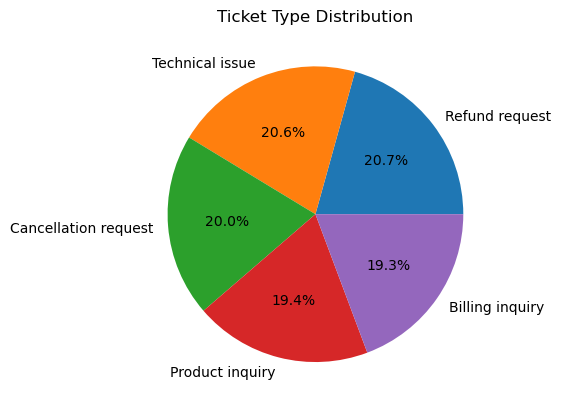

In [45]:
import matplotlib.pyplot as plt

df['ticket_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Ticket Type Distribution")
plt.ylabel("")
plt.show()


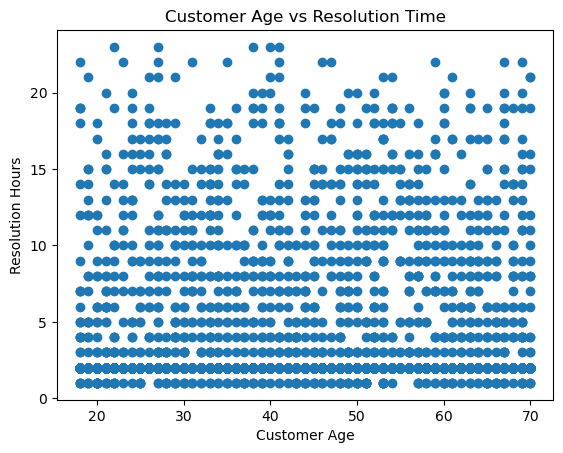

In [46]:
plt.scatter(df['customer_age'], df['resolution_hours'])

plt.title("Customer Age vs Resolution Time")
plt.xlabel("Customer Age")
plt.ylabel("Resolution Hours")
plt.show()


In [47]:
total_missing_values = df.isnull().sum().sum()
print("Total missing values:", total_missing_values)

Total missing values: 0
